# Week 9 Overview

This week will be a mix of data vizualization problems and . 

The first 5 problems are data cleaning and the final 4 problems are linear algebra. 

### Data Visualization

Data visualization is a key part of exploratory data analysis (EDA), a crucial initial step for understanding a dataset and preparing for statistical modeling.

Helps visually answer questions such as:
- what patterns are evident in the data?
- what variables are important?
- does the data have anomalies or outliers?

Data visualization is also used throughout the data analysis process to show results and convey information to stakeholders.

Typically, EDA uses `histograms` & `box plots` to visualize `distribution` of a single continuous variable. `Bar charts` & `scatterplots` are used for `bivariate analysis` - correlation between two variables.


#### Histograms

![histograms](https://raw.githubusercontent.com/brendenwest/cis276/main/images/histograms.png)

Display the distribution of a continuous variable.
- Useful for visualizing the shape, for identifying
patterns or trends, for detecting
outliers, skewness, or multimodality
- Divides data into equal-width intervals (`bins`)
- Height of each `bar` represents frequency or
`count` of observations
- Can also compare the distribution of two
or more variables


#### Box & Whisker Plots

A box plot can show how tightly data is grouped, how the data is skewed, and also the symmetry of data.

![image](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-2.png)

Display `median`, `quartiles`, and outliers.
- Useful for visualizing the distribution and spread.
- Box represents `interquartile range` (IQR)
- Line inside the box represents the median
- Whiskers extend from box to minimum and maximum values within 1.5 times the IQR from the box
- Values outside of this range are considered outliers and plotted as individual points


#### Scatterplots

Scatter (aka X-Y) plots show the relationship between two continuous variables. Also useful for identifying outlier data points.

![scatterplots](https://www.mathsisfun.com/data/images/correlation-examples.svg)



#### Bar Charts

Useful for visualizing distribution of `categorical` variables through relative size of bars.

-  One axis represents categories being compared
- Other axis represents frequency, count, or percentage of each category
- usually has space between bars to avoid confusion with histograms

![bar_chart](https://www.mathsisfun.com/data/images/bar-chart-movies.svg)


### Plotting with matplotlib

matplotlib is python package designed for creating (mostly two-dimensional) publication-quality plots.

It allows interactive plotting from the iPython shell or within Jupyter notebooks

matplotlib can export visualizations to  common vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.).

- plots & plot types
- title & labels
- legends
- subplots
- annotations
- saving plots

### Plotting with pandas

The pandas `plot()` method is a wrapper for matplotlib's pyplot.plot() and produces the same plots, but with simpler syntax for visualizing dataframes.
`.plot()` has several optional parameters. Most notably, the `kind` parameter  determines which kind of plot you’ll create (default is a `line` plot):

- "area" for area plots.
- "bar" for vertical bar charts.
- "barh" for horizontal bar charts.
- "box" for box plots.
- "hexbin" for hexbin plots.
- "hist" for histograms.
- "kde" for kernel density estimate charts.
- "density" an alias for "kde".
- "line" for line graphs.
- "pie" for pie charts.
- "scatter" for scatter plots.

### Plotting with seaborn

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn not only makes it easier than pandas to prepare a wider variety of plots, but supports enhancements for presentation-quality plots.

Seaborn supports several key types of plots:

- **relational** - show the relationship between two numeric variables. Includes scatter plots and line plots
- **categorical** - compare data in different categories
- **distribution** - examine how numeric data is distributed across a range of values. Types of distribution plots are histogram, kernel density estimate (KDE) plot, and empirical cumulative distribution function (ECDF) plot
- **predictive** - plots that are designed for predictive analysis, such as for linear regression models.

#### Seaborn styles

`set_style(style)`
Sets the background style with one of these values: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks` (the default). This style stays in effect until it is changed by another set_style() call.
#### General vs. specific methods

You can create Seaborn plots using the general `relplot()` command, which expects a `kind` parameter.

Alternatively, you can use a specific method - e.g. `lineplot()`, which does not require a `kind` parameter.

The two approaches mostly produce the same result, but the the general methods let you create plots with subplots, while the specific methods don’t.

So the general methods return a `FacetGrid` object that contains an `Axes` object for each subplot. The specific methods return an `Axes` object.

#### Basic Seaborn plot parameters

- data - the DataFrame of data to plot
- kind - the type of plot (general plots only)
- x, y - data columns for the x- and y-axis
- hue -  the column that determines categories to plot, with different color for each category
- palette -  color pallette for the plot
- height - The height of the plot in inches with a default of 5. (general plots only)
- aspect - the ratio of width to height (general plots only)
- legend - options for how the legend will be drawn: `auto` (the default), `brief`, `full`, and `False`. (general plots only)

#### Creating subplots

- By default, x and y labels are shared by subplots
- subplots get their title from the category label

#### Modifying plot features

The `Axes` object that provides methods for enhancing a plot.

#### Saving plots

Seaborn plots can be saved to PNG, SVG, or PDF files. The approach is slightly different for plots created with general or specific methods.

- **General method** - assign the plot's FacetGrid object to a variable and then use the `savefig()` method of the FacetGrid object
- **Specific method** - call the `get_figure()` method on the Axes object  returned by the lineplot() method, then chain go the `savefig()` method

# Data Visualization Problems

For the problems this week we are going to go a step deeper and start to ask questions about our data. 

In [1]:
import pandas as pd
import seaborn as sns

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::disability-and-health-insurance-seattle-neighborhoods/about
dis_health_df = pd.read_csv('seattle_data/disability_health_insurance_Neighborhoods.csv')
dis_health_df.columns = [i.replace(" ", "_") for i in dis_health_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::poverty-and-employment-status-seattle-neighborhoods/about
income_df = pd.read_csv('seattle_data/incomes_Neighborhoods.csv')
income_df.columns = [i.replace(" ", "_") for i in income_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::incomes-occupations-and-earnings-seattle-neighborhoods/about
poverty_df = pd.read_csv('seattle_data/poverty_Neighborhoods.csv')
poverty_df.columns = [i.replace(" ", "_") for i in poverty_df.columns]

## Problem 1: Asking Questions (10 pts)

Take 5 minutes to look through the above data sources as pose 5 analytical questions you might want to ask with that data. By analytical I mean question will drive informative analysis. For example:

**Good Question**: Is there relationship between health insurance coverage and disability?

**Bad Question**: How many neighboorhoods are there?

The second question is the type of question that is is good to ask when processing the data to make sure you processed it correctly but it doesn't give you insights into the data.

At least two of the questions must involve data from at least two of the datasets.

In class you will share your questions with your group and as a group you will pick two questions to focus on for analysis in class. On your own this week you will answer the rest of your questions.

**Grading**
You will receive 2 points per question. One point for forming a question the other for it being a analytical question. 

In [2]:
display(dis_health_df.head())
display(dis_health_df.columns)
display(income_df.head())
display(income_df.columns)
display(poverty_df.head())
display(poverty_df.columns)

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_18_years_and_Over,Population_18_to_64_years,Population_18_to_64_years_Below_Poverty_with_a_Disability,Population_18_to_64_years_Below_Poverty_without_a_Disability,...,Population_65_years_and_Over_with_Health_Insurance,Population_65_years_and_Over_without_Health_Insurance,Population_without_Health_Insurance,Population_under_19_years,Population_19_to_34_years,Population_35_to_64_years,Population_65_years_and_Over.1,Households,Households_with_1_or_more_persons_with_a_disability,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,1.4,Alki/Admiral,CRA,Southwest,5Y23,10131,7910,105,323,...,2221,0,447,1862,2231,5606,2221,5595,865,CRA
1,2,2.1,North Delridge,CRA,Delridge Neighborhoods,5Y23,5213,4629,28,408,...,584,0,520,558,1784,2817,584,3079,452,CRA
2,3,2.2,High Point,CRA,Delridge Neighborhoods,5Y23,6828,6084,128,584,...,744,0,279,2407,2595,3448,744,3709,756,CRA
3,4,2.3,Riverview,CRA,Delridge Neighborhoods,5Y23,3940,3497,29,147,...,437,6,78,1115,1088,2368,443,1878,329,CRA
4,5,2.4,Roxhill/Westwood,CRA,Delridge Neighborhoods,5Y23,11602,10014,397,454,...,1540,48,1043,2559,3605,6212,1588,5825,1171,CRA


Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'Population_18_years_and_Over',
       'Population_18_to_64_years',
       'Population_18_to_64_years_Below_Poverty_with_a_Disability',
       'Population_18_to_64_years_Below_Poverty_without_a_Disability',
       'Population_18_to_64_years_Above_Poverty_with_a_Disability',
       'Population_18_to_64_years_Above_Poverty_without_a_Disability',
       'Population_65_years_and_Over',
       'Population_65_years_and_Over_Below_Poverty_with_a_Disability',
       'Population_65_years_and_Over_Below_Poverty_without_a_Disability',
       'Population_65_years_and_Over_Above_Poverty_with_a_Disability',
       'Population_65_years_and_Over_Above_Poverty_without_a_Disability',
       'Population_18_years_and_Over_with_a_Disability',
       'Population_18_to_64_years_with_a_Disability',
       'Population_65_years_and_Over_with_a_Disability',
       'Population_Civilian_Noninstit

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars),Total_Population,Total_Households,"Household_Income_Less_than_$10,000",...,"Family_Household_Income_$100,000_or_more","Nonfamily_Household_Income_$100,000_or_more","Earnings_$50,000_or_More_Male_Workers","Earnings_$50,000_or_More_Female_Workers",Population_16_years_and_over_with_earnings,Males_16_years_and_over_with_earnings,Females_16_years_and_over_with_earnings,"Earnings_$50,000_or_More_All_Workers",Aggregate_Household_Income,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,1.0,Council District 1,CD,NaN,5Y23,7965084000,108594,48209,NaN,...,18306,9460,25368,19332,69022,36599,32423,44700,7797458400,CD
1,2,2.0,Council District 2,CD,NaN,5Y23,6355394800,108053,43824,NaN,...,14263,6486,20961,14994,66298,35636,30662,35955,6177651600,CD
2,3,3.0,Council District 3,CD,NaN,5Y23,10763937200,108012,60156,NaN,...,14102,18831,30371,22452,79057,43795,35262,52823,10593211500,CD
3,4,4.0,Council District 4,CD,NaN,5Y23,7692298500,104299,42569,NaN,...,15438,7902,21817,15841,70502,35778,34724,37658,7471995100,CD
4,5,5.0,Council District 5,CD,NaN,5Y23,7324865100,106208,47887,NaN,...,16110,8266,23739,18286,68025,36815,31210,42025,7154789000,CD


Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage',
       'Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars)',
       'Total_Population', 'Total_Households',
       'Household_Income_Less_than_$10,000',
       'Household_Income_$10,000_to_$14,999',
       'Household_Income_$15,000_to_$24,999',
       'Household_Income_$25,000_to_$34,999',
       'Household_Income_$35,000_to_$49,999',
       'Household_Income_$50,000_to_$74,999',
       'Household_Income_$75,000_to_$99,999',
       'Household_Income_$100,000_to_$149,999',
       'Household_Income_$150,000_to_$199,999',
       'Household_Income_$200,000_or_more', 'Total_Family_Households',
       'Family_Household_Income_Less_than_$10,000',
       'Family_Household_Income_$10,000_to_$14,999',
       'Family_Household_Income_$15,000_to_$24,999',
       'Family_Household_Income_$25,000_to_$34,999',
       'Family_Household_Income_$35,000_to_$49,9

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_16_years_and_over,Population_16_years_and_over_not_in_labor_force,Population_16_years_and_over_in_civilian_labor_force,Population_16_years_and_over_in_civilian_labor_force_unemployed,...,Population_20_to_64_years_employed,Population_20_to_64_years_below_poverty_employed,People_with_Income_to_Poverty_below_2.00,Population_20_to_64_years_in_civilian_labor_force,Population_20_to_64_years_in_civilian_labor_force_below_poverty,Population_20_to_64_years_not_in_labor_force,Population_20_to_64_years_not_in_labor_force_below_poverty,Population_20_to_64_years_unemployed,Population_20_to_64_years_unemployed_below_poverty,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,8.2,Olympic Hills/Victory Heights,CRA,North,5Y23,14516,3751,10745,574,...,9637,392,2951,10165,594,1448,293,528,202,CRA
1,2,8.3,Cedar Park/Meadowbrook,CRA,North,5Y23,12513,3677,8836,259,...,7774,250,2807,7985,321,1404,522,211,71,CRA
2,3,9.1,Broadview/Bitter Lake,CRA,Northwest,5Y23,13260,4753,8507,356,...,7454,285,3261,7776,371,1519,490,322,86,CRA
3,4,9.2,Licton Springs,CRA,Northwest,5Y23,8798,1895,6903,267,...,6339,201,2081,6601,301,1008,411,262,100,CRA
4,5,9.3,Greenwood/Phinney Ridge,CRA,Northwest,5Y23,23396,4985,18381,565,...,16629,324,2613,17105,456,2188,430,476,132,CRA


Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'Population_16_years_and_over',
       'Population_16_years_and_over_not_in_labor_force',
       'Population_16_years_and_over_in_civilian_labor_force',
       'Population_16_years_and_over_in_civilian_labor_force_unemployed',
       'Population_for_whom_poverty_status_is_determined',
       'People_with_Income_to_Poverty_Ratio_Under_.50',
       'People_with_Income_to_Poverty .50_to_.99',
       'People_with_Income_to_Poverty_1.00_to_1.24',
       'People_with_Income_to_Poverty 1.25_to_1.49',
       'People_with_Income_to_Poverty 1.50_to_1.84',
       'People_with_Income_to_Poverty 1.85_to_1.99',
       'People_with_Income_to_Poverty_2.00_and_over',
       'Families_for_whom_poverty_status_is_determined',
       'Families_with_income_in_the_past_12_months_below_poverty_level',
       'Married-couple_family_with_related_children_of_the_householder_under_18_years_below

## Question 1
- Are neighborhoods with higher percentages of people under 19 more likely to have higher rates of no insurance? 
- Again for under 19 *and* 18-34?
## Question 2
- Is there a relationship between poverty and disability?
## Question 3
- Do the top 5 neighborhoods by mean income have lower rates of disability than the bottom 5?
## Question 4
- What is the relationship between household income and insurance coverage?
## Question 5
- 

## Problem 2: Data Cleaning and Merging (10 pts)

Take a few minutes to prepare your data for analysis. You can decide what preparation is required but you must at least perform two of the following to receive credit. You might find that you start to create a graph and then need to prepare the data better (i.e. remove an outlier) that is expected.

1. Clean up the column names.
2. Merge dataframes together. 
3. Fill in null values.
4. Removing outliers. 
5. Change the shape of the data (We will learn aggregations next week but if you know how feel free to use them).
6. Any other preparation required to answer your questions.

For each preparation step add a comment to explain why you did that step. 

**Grading** You will receive 5 points for the first two data prep steps you perform. 2 point will be for the comment and then 3 points will be for accurately performing the prep. 

In [9]:
# Dropping an extra instance of a column
dis_health_df.drop(columns=['Population_65_years_and_Over.1'], inplace=True, errors='ignore')
# Trimming column names in dis_health_df
dis_health_df.rename(columns={
    'Population_18_years_and_Over': 'pop_18_plus',
    'Population_18_to_64_years': 'pop_18_64',
    'Population_18_to_64_years_Below_Poverty_with_a_Disability': 'pop_18_64_poverty_w_disability',
    'Population_18_to_64_years_Below_Poverty_without_a_Disability': 'pop_18_64_poverty_no_disability',
    'Population_18_to_64_years_Above_Poverty_with_a_Disability': 'pop_18_64_no_poverty_w_disability',
    'Population_18_to_64_years_Above_Poverty_without_a_Disability': 'pop_18_64_no_poverty_no_disability',
    'Population_65_years_and_Over': 'pop_65_plus',
    'Population_65_years_and_Over_Below_Poverty_with_a_Disability': 'pop_65_plus_poverty_w_disability',
    'Population_65_years_and_Over_Below_Poverty_without_a_Disability': 'pop_65_plus_poverty_no_disability',
    'Population_65_years_and_Over_Above_Poverty_with_a_Disability': 'pop_65_plus_no_poverty_w_disability',
    'Population_65_years_and_Over_Above_Poverty_without_a_Disability': 'pop_65_plus_no_poverty_no_disability',
    'Population_18_years_and_Over_with_a_Disability': 'pop_18_plus_w_disability',
    'Population_18_to_64_years_with_a_Disability': 'pop_18_64_w_disability',
    'Population_65_years_and_Over_with_a_Disability': 'pop_65_plus_w_disability',
    'Population_Civilian_Noninstitutionalized': 'noninstitutionalized',
    'Population_under_19_years_with_Health_Insurance': 'pop_under_19_w_insurance',
    'Population_under_19_years_without_Health_Insurance': 'pop_under_19_no_insurance',
    'Population_19_to_34_years_with_Health_Insurance': 'pop_19_34_w_insurance',
    'Population_19_to_34_years_without_Health_Insurance': 'pop_19_34_no_insurance',
    'Population_35_to_64_years_with_Health_Insurance': 'pop_35_64_w_insurance',
    'Population_35_to_64_years_without_Health_Insurance': 'pop_35_64_no_insurance',
    'Population_65_years_and_Over_with_Health_Insurance': 'pop_65_plus_w_insurance',
    'Population_65_years_and_Over_without_Health_Insurance': 'pop_65_plus_no_insurance',
    'Population_without_Health_Insurance': 'pop_no_insurance',
    'Population_under_19_years': 'pop_under_19',
    'Population_19_to_34_years': 'pop_19_34',
    'Population_35_to_64_years': 'pop_35_64',
    'Households_with_1_or_more_persons_with_a_disability': 'households_w_disability',
    'Neighborhood_Type_(outside_comp_plan_areas_id)': 'neighborhood_type'
}, inplace= True)
dis_health_df.columns

Index(['NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'pop_18_plus', 'pop_18_64',
       'pop_18_64_poverty_w_disability', 'pop_18_64_poverty_no_disability',
       'pop_18_64_no_poverty_w_disability',
       'pop_18_64_no_poverty_no_disability', 'pop_65_plus',
       'pop_65_plus_poverty_w_disability', 'pop_65_plus_poverty_no_disability',
       'pop_65_plus_no_poverty_w_disability',
       'pop_65_plus_no_poverty_no_disability', 'pop_18_plus_w_disability',
       'pop_18_64_w_disability', 'pop_65_plus_w_disability',
       'noninstitutionalized', 'pop_under_19_w_insurance',
       'pop_under_19_no_insurance', 'pop_19_34_w_insurance',
       'pop_19_34_no_insurance', 'pop_35_64_w_insurance',
       'pop_35_64_no_insurance', 'pop_65_plus_w_insurance',
       'pop_65_plus_no_insurance', 'pop_no_insurance', 'pop_under_19',
       'pop_19_34', 'pop_35_64', 'pop_65_plus', 'Households',
       'households_w_disability', 'neighborhood_typ

In [4]:
# Trimming column names in income_df
income_df.rename(columns={
    'Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars)': 'income_past_12_mo',
    'Total_Population': 'total_pop',
    'Total_Households': 'total_households',
    'Household_Income_Less_than_$10,000': 'income_sub_10k',
    'Household_Income_$10,000_to_$14,999': 'income_10k_15k',
    'Household_Income_$15,000_to_$24,999': 'income_15k_25k',
    'Household_Income_$25,000_to_$34,999': 'income_25k_35k',
    'Household_Income_$35,000_to_$49,999': 'income_35k_50k',
    'Household_Income_$50,000_to_$74,999': 'income_50k_75k',
    'Household_Income_$75,000_to_$99,999': 'income_75k_100k',
    'Household_Income_$100,000_to_$149,999': 'income_100k_150k',
    'Household_Income_$150,000_to_$199,999': 'income_150k_200k',
    'Household_Income_$200,000_or_more': 'income_200k_plus',
    'Total_Family_Households': 'family_total_households',
    'Family_Household_Income_Less_than_$10,000': 'family_income_sub_10k',
    'Family_Household_Income_$10,000_to_$14,999': 'family_income_10k_15k',
    'Family_Household_Income_$15,000_to_$24,999': 'family_income_15k_25k',
    'Family_Household_Income_$25,000_to_$34,999': 'family_income_25k_35k',
    'Family_Household_Income_$35,000_to_$49,999': 'family_income_35k_50k',
    'Family_Household_Income_$50,000_to_$74,999': 'family_income_50k_75k',
    'Family_Household_Income_$75,000_to_$99,999': 'family_income_75k_100k',
    'Family_Household_Income_$100,000_to_$149,999': 'family_income_100k_150k',
    'Family_Household_Income_$150,000_to_$199,999': 'family_income_150k_200k',
    'Family_Household_Income_$200,000_or_more': 'family_income_200k_plus',
    'Total_Nonfamily_Households': 'nonfamily_total_households',
    'Nonfamily_Household_Income_Less_than_$10,000': 'nonfamily_income_sub_10k',
    'Nonfamily_Household_Income_$10,000_to_$14,999': 'nonfamily_income_10k_15k',
    'Nonfamily_Household_Income_$15,000_to_$24,999': 'nonfamily_income_15k_25k',
    'Nonfamily_Household_Income_$25,000_to_$34,999': 'nonfamily_income_25k_35k',
    'Nonfamily_Household_Income_$35,000_to_$49,999': 'nonfamily_income_35k_50k',
    'Nonfamily_Household_Income_$50,000_to_$74,999': 'nonfamily_income_50k_75k',
    'Nonfamily_Household_Income_$75,000_to_$99,999': 'nonfamily_income_75k_100k',
    'Nonfamily_Household_Income_$100,000_to_$149,999': 'nonfamily_income_100k_150k',
    'Nonfamily_Household_Income_$150,000_to_$199,999': 'nonfamily_income_150k_200k',
    'Nonfamily_Household_Income_$200,000_or_more': 'nonfamily_income_200k_plus',
    'Management,_business,_science,_and_arts_occupations': 'mgmt_bus_sci_arts_jobs',
    'Service_occupations': 'service_jobs',
    'Sales_and_office_occupations': 'sales_office_jobs',
    'Natural_resources,_construction,_and_maintenance_occupations': 'nat_resource_construct_maint_jobs',
    'Production,_transportation,_and_material_moving_occupations': 'prod_transport_material_moving_jobs',
    'Earnings_Male_less_than_$10,000': 'male_income_sub_10k',
    'Earnings_Male_$10,000_to_$19,999': 'male_income_10k_20k',
    'Earnings_Male_$20,000_to_$39,999': 'male_income_20k_40k',
    'Earnings_Male_$40,000_to_$74,999': 'male_income_40k_75k',
    'Earnings_Male_$75,000_to_$99,999': 'male_income_75k_100k',
    'Earnings_Male_$100,000_or_more': 'male_income_100k_plus',
    'Earnings_Female_less_than_$10,000': 'female_income_sub_10k',
    'Earnings_Female_$10,000_to_$19,999': 'female_income_10k_20k',
    'Earnings_Female_$20,000_to_$39,999': 'female_income_20k_40k',
    'Earnings_Female_$40,000_to_$74,999': 'female_income_40k_75k',
    'Earnings_Female_$75,000_to_$99,999': 'female_income_75k_100k',
    'Earnings_Female_$100,000_or_more': 'female_income_100k_plus',
    'Household_Income_$100,000_or_more': 'household_income_100k_plus',
    'Family_Household_Income_$100,000_or_more': 'family_household_income_100k_plus',
    'Nonfamily_Household_Income_$100,000_or_more': 'nonfamily_household_income_100k_plus',
    'Earnings_$50,000_or_More_Male_Workers': 'male_income_50k_plus',
    'Earnings_$50,000_or_More_Female_Workers': 'female_income_50k_plus',
    'Population_16_years_and_over_with_earnings': 'pop_16_plus_w_earnings',
    'Males_16_years_and_over_with_earnings': 'male_16_plus_w_earnings',
    'Females_16_years_and_over_with_earnings': 'female_16_plus_w_earnings',
    'Earnings_$50,000_or_More_All_Workers': 'all_income_50k_plus',
    'Neighborhood_Type_(outside_comp_plan_areas_id)': 'neighborhood_type'
}, inplace=True)
income_df.columns

Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'income_past_12_mo',
       'total_pop', 'total_households', 'income_sub_10k', 'income_10k_15k',
       'income_15k_25k', 'income_25k_35k', 'income_35k_50k', 'income_50k_75k',
       'income_75k_100k', 'income_100k_150k', 'income_150k_200k',
       'income_200k_plus', 'family_total_households', 'family_income_sub_10k',
       'family_income_10k_15k', 'family_income_15k_25k',
       'family_income_25k_35k', 'family_income_35k_50k',
       'family_income_50k_75k', 'family_income_75k_100k',
       'family_income_100k_150k', 'family_income_150k_200k',
       'family_income_200k_plus', 'Total_Nonfamily_Housholds',
       'nonfamily_income_sub_10k', 'nonfamily_income_10k_15k',
       'nonfamily_income_15k_25k',
       'Nonfamily_Household_Income__$25,000_to_$34,999',
       'nonfamily_income_35k_50k', 'nonfamily_income_50k_75k',
       'nonfamily_income_75k_100k', 'nonfamil

In [5]:
# Trimming column names in poverty_df
poverty_df.columns.str.strip()
poverty_df.rename(columns={
    'Population_16_years_and_over': 'pop_16_plus',
    'Population_16_years_and_over_not_in_labor_force': 'pop_16_plus_no_work',
    'Population_16_years_and_over_in_civilian_labor_force': 'pop_16_plus_w_work',
    'Population_16_years_and_over_in_civilian_labor_force_unemployed': 'pop_16_plus_unemployed',
    'Population_for_whom_poverty_status_is_determined': 'pop_poverty_status_known',
    'People_with_Income_to_Poverty_Ratio_Under_.50': 'income_to_poverty_sub_.50',
    'People_with_Income_to_Poverty .50_to_.99': 'income_to_poverty_.50_.99',
    'People_with_Income_to_Poverty_1.00_to_1.24': 'income_to_poverty_1.00_1.24',
    'People_with_Income_to_Poverty 1.25_to_1.49': 'income_to_poverty_1.25_1.49',
    'People_with_Income_to_Poverty 1.50_to_1.84': 'income_to_poverty_1.50_1.84',
    'People_with_Income_to_Poverty 1.85_to_1.99': 'income_to_poverty_1.85_1.99',
    'People_with_Income_to_Poverty_2.00_and_over': 'income_to_poverty_2.00_plus',
    'Families_for_whom_poverty_status_is_determined': 'families_poverty_status_known',
    'Families_with_income_in_the_past_12_months_below_poverty_level': 'families_below_poverty_income_past_year',
    'Married-couple_family_with_related_children_of_the_householder_under_18_years_below_poverty': 'married_w_children_sub_18_poverty',
    'Married-couple_family_without_related_children_of_the_householder_under_18_years_below_poverty': 'married_no_children_sub_18_poverty',
    'Single_parents_with_related_children_of_the_householder_under_18_years_below_poverty': 'single_w_children_sub_18_poverty',
    'Other_family_below_poverty': 'other_family_poverty',
    'Population_20_to_64_years_for_whom_poverty_status_is_determined': 'pop_20_64_poverty_status_known',
    'Population_20_to_64_years_below_poverty': 'pop_20_64_poverty',
    'Population_20_to_64_years_employed': 'pop_20_64_work',
    'Population_20_to_64_years_below_poverty_employed': 'pop_20_64_poverty_plus_work',
    'People_with_Income_to_Poverty_below_2.00': 'income_to_poverty_sub_2.00',
    'Population_20_to_64_years_in_civilian_labor_force': 'pop_20_64_work',
    'Population_20_to_64_years_in_civilian_labor_force_below_poverty': 'pop_20_64_work_plus_poverty',
    'Population_20_to_64_years_not_in_labor_force': 'pop_20_64_no_work',
    'Population_20_to_64_years_not_in_labor_force_below_poverty': 'pop_20_64_no_work_plus_poverty',
    'Population_20_to_64_years_unemployed': 'pop_20_64_unemployed',
    'Population_20_to_64_years_unemployed_below_poverty': 'pop_20_64_unemployed_plus_poverty',
    'Neighborhood_Type_(outside_comp_plan_areas_id)': 'neighborhood_type'
}, inplace=True)
poverty_df.columns

Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'pop_16_plus',
       'pop_16_plus_no_work', 'pop_16_plus_w_work', 'pop_16_plus_unemployed',
       'pop_poverty_status_known', 'income_to_poverty_sub_.50',
       'People_with_Income_to_Poverty .50_to_.99',
       'income_to_poverty_1.00_1.24',
       'People_with_Income_to_Poverty 1.25_to_1.49',
       'People_with_Income_to_Poverty 1.50_to_1.84',
       'People_with_Income_to_Poverty 1.85_to_1.99',
       'income_to_poverty_2.00_plus', 'families_poverty_status_known',
       'families_below_poverty_income_past_year',
       'married_w_children_sub_18_poverty',
       'married_no_children_sub_18_poverty',
       'single_w_children_sub_18_poverty', 'other_family_poverty',
       'pop_20_64_poverty_status_known', 'pop_20_64_poverty', 'pop_20_64_work',
       'pop_20_64_poverty_plus_work', 'income_to_poverty_sub_2.00',
       'pop_20_64_work', 'pop_20_64_work_plus_pove

In [ ]:
# Merging the three dataframes

# List of columns to merge on
merge_cols = [
    'NEIGH_NO', 
    'Neighborhood_Name', 
    'Neighborhood_Type', 
    'Neighborhood_Subtype', 
    'ACS_Vinatage', 
    'neighborhood_type'
]

# Dropping problematic column
dis_health_df = dis_health_df.drop(columns=['OBJECTID'], errors='ignore')
income_df = income_df.drop(columns=['OBJECTID'], errors='ignore')
poverty_df = poverty_df.drop(columns=['OBJECTID'], errors='ignore')

# The actual merge
df = pd.merge(dis_health_df, income_df, on= merge_cols, how='outer')
df = pd.merge(df, poverty_df, on= merge_cols, how='outer')

# Dropping unnecessary column
df.drop(columns='ACS_Vinatage', inplace= True)

# Checking the final merge
df.head()

,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,pop_18_plus,pop_18_64,pop_18_64_poverty_w_disability,pop_18_64_poverty_no_disability,pop_18_64_no_poverty_w_disability,pop_18_64_no_poverty_no_disability,...,pop_20_64_poverty,pop_20_64_work,pop_20_64_poverty_plus_work,income_to_poverty_sub_2.00,pop_20_64_work,pop_20_64_work_plus_poverty,pop_20_64_no_work,pop_20_64_no_work_plus_poverty,pop_20_64_unemployed,pop_20_64_unemployed_plus_poverty
0,0.0,Outside Villages,UCUV,Outside Villages,328594,270586,4007,14261,14256,238062,...,17835,220723,6877,52811,228766,9049,37097,8786,8043,2172
1,1.0,Council District 1,CD,NaN,88565,74387,1793,4560,5057,62977,...,6201,59708,2159,18896,62376,2983,10629,3218,2668,824
2,1.1,Arbor Heights,CRA,Southwest,4736,3638,40,130,265,3203,...,170,2912,32,406,2998,63,558,107,86,31
3,1.2,Fauntleroy/Seaview,CRA,Southwest,12332,9907,134,504,423,8846,...,597,8271,251,1583,8537,380,1209,217,266,129
4,1.3,West Seattle Junction/Genesee Hill,CRA,Southwest,19582,16724,177,814,1197,14536,...,991,14013,640,3421,14638,680,1824,311,625,40


## Problem 3: Question 1 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

## Question 1
- Are neighborhoods with higher percentages of people under 19 more likely to have higher rates of no insurance? 
- Again for under 19 *and* 18-34?

C:\Users\oi12b\AppData\Local\Temp\ipykernel_15352\991264173.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q1_df['pct_under_19'] = q1_df['pop_under_19'] / q1_df['total_pop'] * 100
C:\Users\oi12b\AppData\Local\Temp\ipykernel_15352\991264173.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q1_df['pct_no_insurance'] = q1_df['pop_no_insurance'] / q1_df['total_pop'] * 100


<Axes: title={'center': 'Relationship Between Youth and No Insurance'}, xlabel='pct_under_19', ylabel='pct_no_insurance'>

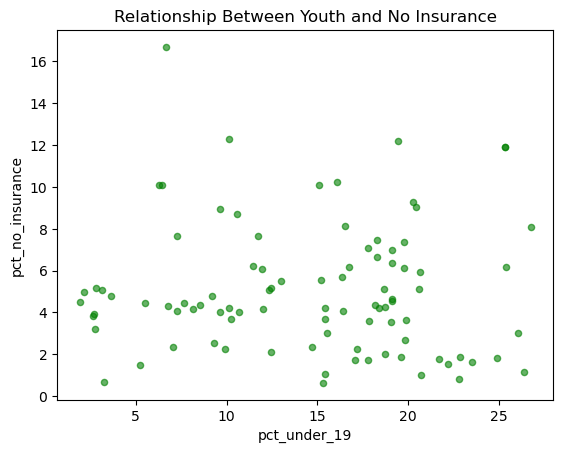

In [ ]:
q1_df = df[['Neighborhood_Name', 'pop_under_19', 'pop_no_insurance', 'total_pop']]
q1_df['pct_under_19'] = q1_df['pop_under_19'] / q1_df['total_pop'] * 100
q1_df['pct_no_insurance'] = q1_df['pop_no_insurance'] / q1_df['total_pop'] * 100
# q1_df.plot(kind='line')
# print(q1_df)
q1_df.plot(
    kind='scatter',
    x='pct_under_19',
    y='pct_no_insurance',
    title='Relationship Between Youth and No Insurance', # Added descriptive title to graph
    color='green',  # Changed color for aesthetics
    alpha=0.6       # Slight transparancy to better see overlaps
)

## Problem 4: Question 2 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

## Question 2
- Is there a relationship between poverty and disability?

In [8]:
q2_df = df[['families_below_poverty_income_past_year', 'households_w_disability']]

KeyError: "['households_w_disability'] not in index"

## Problem 5: Question 3 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

## Question 3
- Do the top 5 neighborhoods by mean income have lower rates of disability than the bottom 5?

## Problem 6: Question 4 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

## Question 4
- What is the relationship between household income and insurance coverage?

## Problem 7: Question 5 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

## Problem 8 (10pts)
Pick 5 columns in the datasets above and create a covariance by completing the following steps:

1. Mean center all columns. You can use panda's mean function for this. 
2. Create a covariance matrix as follows:
$$ C = X^T X \dfrac{1}{n-1}$$
3. You should save this to a dateframe called `cov_df` to be used in the next problem. 
4. Output the results of `cov_df` and visually check your results against [DataFrame.cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html). The numbers should match. 

## Problem 9 (10pts)

Next you will take the `cov_df` and create a correlation matrix from it. The formula for this is

$$ R = SCS $$

Where $C$ is the covariance matrix `cov_df`, and $S$ is a diagonal matrix of reciprocated standard deviations per variable (that is, the ith diagonal is $\dfrac{1}{\sigma_i}$ where $\sigma_i$ is the standard deviation of variable i). You can use panda's standard deviation function to create $S$. 

Once you have created the correlation matrix visually compare it to [np.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)